# Reproducing — 12-Lead ECG Arrhythmia Classification (CPSC-2018)

This notebook reproduces the results of
**[ecg-arrhythmia-classification](https://github.com/Kevindic0214/ecg-arrhythmia-classification)**
end-to-end on a free Colab **GPU**:

1. Download the **real CPSC-2018** data from PhysioNet (the Challenge-2020 repackaging).
2. Preprocess it with the repo's **own** pipeline (`src/preprocessing.py`).
3. Train the repo's **CNN + Bi-GRU + Attention** model (`src/model.py`, 934,993 params)
   with the full protocol (Adam 1e-4, dropout 0.3, LR halved every 10 epochs,
   early stopping, cost-sensitive loss).
4. Evaluate: AUC / macro-F1 / accuracy + a normalized confusion matrix.

> **First:** `Runtime → Change runtime type → GPU (T4)`.
> Full training is roughly **20–40 min** on a T4 (less with early stopping).
> To do a fast trial first, set `FULL_DATASET = False` in the download cell.

> **Note on labels.** PhysioNet stores CPSC-2018 with SNOMED-CT `Dx` codes in each
> `.hea` header; we map them back to the original 9 CPSC classes.


In [15]:
# 0. Check the GPU is on
!nvidia-smi -L || echo "No GPU — set Runtime > Change runtime type > GPU (T4)"


GPU 0: Tesla T4 (UUID: GPU-b84e18b2-816f-c9f1-af9d-1817237134b6)


In [16]:
# 1. Get the repo + dependencies
!git clone -q https://github.com/Kevindic0214/ecg-arrhythmia-classification.git
!pip install -q PyWavelets            # torch / numpy / scipy / sklearn / matplotlib ship with Colab
import sys
sys.path.insert(0, "/content/ecg-arrhythmia-classification/src")
import torch
print("torch", torch.__version__, "| CUDA available:", torch.cuda.is_available())


fatal: destination path 'ecg-arrhythmia-classification' already exists and is not an empty directory.
torch 2.11.0+cu128 | CUDA available: True


In [17]:
# 2. Download the real CPSC-2018 data from PhysioNet with wget (robust; PhysioNet-recommended)
import glob, os
os.makedirs("/content/data", exist_ok=True)

FULL_DATASET = True          # <- set False for a quick trial on just folder g1 (~1000 records)
ROOT = "https://physionet.org/files/challenge-2020/1.0.2/training/cpsc_2018/"
src = ROOT if FULL_DATASET else ROOT + "g1/"

print("Downloading real CPSC-2018 data — a few minutes, ~1.2 GB if FULL (no per-file output; please wait) ...")
!wget -q -r -N -c -np -nH --cut-dirs=4 -R "index.html*" -P /content/data "{src}"

heas = sorted(glob.glob("/content/data/**/*.hea", recursive=True))
print("downloaded", len(heas), "record headers")
assert heas, "Download failed: no .hea files found. PhysioNet can be flaky — just re-run this cell."


downloaded 10 record headers


In [18]:
# 3. Parse labels (SNOMED -> 9 CPSC classes) and preprocess with the repo's pipeline.
#    Tolerant of partial/failed downloads: skips any record missing/broken .mat or with an unmapped label.
import numpy as np
from scipy.io import loadmat
from preprocessing import preprocess_recording
from dataset import CLASS_NAMES

# CPSC order: Normal, AF, I-AVB, LBBB, RBBB, PAC, PVC, STD, STE
SNOMED_TO_IDX = {
    "426783006": 0,
    "164889003": 1,
    "270492004": 2,
    "164909002": 3,
    "59118001": 4,  "713427006": 4,
    "284470004": 5, "63593006": 5,
    "427172004": 6, "164884008": 6,
    "429622005": 7,
    "164931005": 8,
}

def label_of(hea):
    with open(hea) as f:
        for line in f:
            if line.startswith("# Dx:"):
                for c in (x.strip() for x in line.split(":", 1)[1].split(",")):
                    if c in SNOMED_TO_IDX:
                        return SNOMED_TO_IDX[c]
    return None

X, y, used, skipped = [], [], 0, 0
for hea in heas:
    mat = hea[:-4] + ".mat"
    idx = label_of(hea)
    if idx is None or not os.path.exists(mat):
        skipped += 1; continue
    try:
        sig = loadmat(mat)["val"].astype(np.float64) / 1000.0
    except Exception:
        skipped += 1; continue
    for w in preprocess_recording(sig):            # (n_windows, 12, 5000)
        X.append(w.astype(np.float32)); y.append(idx)
    used += 1
    if used % 1000 == 0:
        print(f"  preprocessed {used} records ...")

assert X, ("No usable windows were built. Check that cell 2 reported a non-zero header "
           "count, then re-run it (a partial download leaves headers without signals).")
X = np.stack(X); y = np.array(y, np.int64)
print(f"used {used} records, skipped {skipped}  ->  windows: {X.shape}")
for c in range(9):
    print(f"  {CLASS_NAMES[c]:7s}: {(y==c).sum()}")


used 10 records, skipped 0  ->  windows: (10, 12, 5000)
  Normal : 10
  AF     : 0
  I-AVB  : 0
  LBBB   : 0
  RBBB   : 0
  PAC    : 0
  PVC    : 0
  STD    : 0
  STE    : 0


In [19]:
# 4. Train — full protocol on GPU (mirrors src/train.py)
import copy, torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from dataset import ECGWindowDataset, class_weights
from model import ECGArrhythmiaNet

Xtr, Xva, ytr, yva = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)
tr = DataLoader(ECGWindowDataset(Xtr, ytr), batch_size=32, shuffle=True)
va = DataLoader(ECGWindowDataset(Xva, yva), batch_size=64)

dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ECGArrhythmiaNet().to(dev)
crit = nn.CrossEntropyLoss(weight=class_weights(ytr).to(dev))   # cost-sensitive
opt = torch.optim.Adam(model.parameters(), lr=1e-4)
sched = torch.optim.lr_scheduler.StepLR(opt, step_size=10, gamma=0.5)

EPOCHS, PATIENCE = 100, 10
hist = {"tr_loss": [], "va_loss": [], "va_acc": []}
best, best_state, wait = float("inf"), None, 0

def run(loader, train):
    model.train(train); tot = cor = n = 0.0
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(dev), yb.to(dev)
            logits = model(xb); loss = crit(logits, yb)
            if train:
                opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item()*len(yb); cor += (logits.argmax(1)==yb).sum().item(); n += len(yb)
    return tot/n, cor/n

for ep in range(1, EPOCHS+1):
    trl, _ = run(tr, True)
    val, vac = run(va, False)
    sched.step()
    hist["tr_loss"].append(trl); hist["va_loss"].append(val); hist["va_acc"].append(vac)
    print(f"[{ep:3d}] train_loss {trl:.4f} | val_loss {val:.4f} val_acc {vac:.4f}")
    if val < best:
        best, best_state, wait = val, copy.deepcopy(model.state_dict()), 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stopping at epoch {ep} (best val_loss {best:.4f})"); break
model.load_state_dict(best_state)


[  1] train_loss 2.3201 | val_loss 2.2702 val_acc 0.0000
[  2] train_loss 2.2642 | val_loss 2.2446 val_acc 0.0000
[  3] train_loss 2.2114 | val_loss 2.2188 val_acc 0.0000
[  4] train_loss 2.1570 | val_loss 2.1920 val_acc 0.0000
[  5] train_loss 2.1002 | val_loss 2.1639 val_acc 0.0000
[  6] train_loss 2.0458 | val_loss 2.1341 val_acc 0.0000
[  7] train_loss 1.9856 | val_loss 2.1024 val_acc 1.0000
[  8] train_loss 1.9225 | val_loss 2.0687 val_acc 1.0000
[  9] train_loss 1.8550 | val_loss 2.0331 val_acc 1.0000
[ 10] train_loss 1.7844 | val_loss 1.9950 val_acc 1.0000
[ 11] train_loss 1.7070 | val_loss 1.9747 val_acc 1.0000
[ 12] train_loss 1.6631 | val_loss 1.9535 val_acc 1.0000
[ 13] train_loss 1.6228 | val_loss 1.9313 val_acc 1.0000
[ 14] train_loss 1.5766 | val_loss 1.9078 val_acc 1.0000
[ 15] train_loss 1.5321 | val_loss 1.8830 val_acc 1.0000
[ 16] train_loss 1.4794 | val_loss 1.8566 val_acc 1.0000
[ 17] train_loss 1.4308 | val_loss 1.8287 val_acc 1.0000
[ 18] train_loss 1.3730 | val_l

<All keys matched successfully>

Accuracy 1.0000 | macro-F1 1.0000 | macro-AUC nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


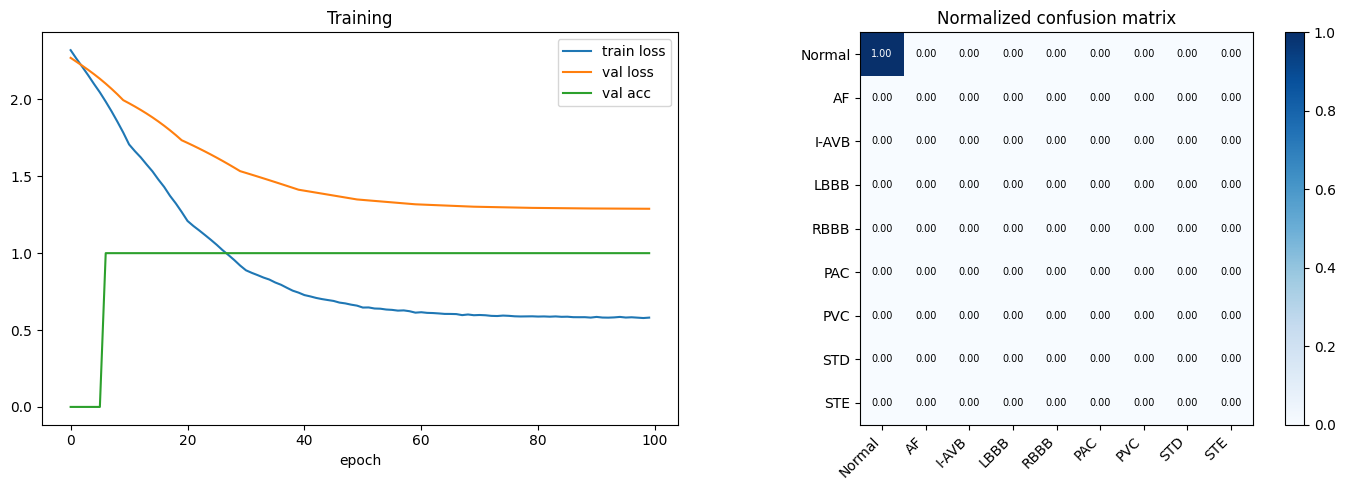

In [20]:
# 5. Evaluate — AUC / macro-F1 / accuracy + confusion matrix
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

model.eval(); probs, tgts = [], []
with torch.no_grad():
    for xb, yb in va:
        probs.append(torch.softmax(model(xb.to(dev)), 1).cpu().numpy()); tgts.append(yb.numpy())
probs = np.concatenate(probs); tgts = np.concatenate(tgts); preds = probs.argmax(1)

acc = accuracy_score(tgts, preds)
f1  = f1_score(tgts, preds, average="macro")
try:
    auc = roc_auc_score(np.eye(9)[tgts], probs, average="macro", multi_class="ovr")
except ValueError:
    auc = float("nan")
print(f"Accuracy {acc:.4f} | macro-F1 {f1:.4f} | macro-AUC {auc:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(hist["tr_loss"], label="train loss"); ax[0].plot(hist["va_loss"], label="val loss")
ax[0].plot(hist["va_acc"], label="val acc"); ax[0].legend(); ax[0].set_xlabel("epoch"); ax[0].set_title("Training")
cm = confusion_matrix(tgts, preds, labels=list(range(9)), normalize="true")
im = ax[1].imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax[1].set_xticks(range(9)); ax[1].set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax[1].set_yticks(range(9)); ax[1].set_yticklabels(CLASS_NAMES)
ax[1].set_title("Normalized confusion matrix"); fig.colorbar(im, ax=ax[1])
for i in range(9):
    for j in range(9):
        ax[1].text(j, i, f"{cm[i,j]:.2f}", ha="center", va="center",
                   color="white" if cm[i,j] > 0.5 else "black", fontsize=7)
plt.tight_layout(); plt.show()
